In [1]:
# ── Cell 1 — imports, path & reload ───────────────────────────────────────────
import sys, os, importlib, warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
sys.path.insert(0, os.path.abspath('../../model'))
sys.path.insert(0, os.path.abspath('.'))
sys.path.insert(0, os.path.abspath('../.'))

import numpy as np
import matplotlib.pyplot as plt
import xso
from xso.parscans import run_xso_parscan, run_xso_stabilityscan, avg_tail

import cariaco_obs as co
import cariaco_baseline_setups as cbs
import parscan_utils as pu
import parscan_plots as pp
for m in (co, cbs, pu, pp):            # pick up edits without a kernel restart
    importlib.reload(m)

phyto_esd, zoo_esd = cbs.phyto_esd, cbs.zoo_esd
print(f'grid: {len(phyto_esd)} phyto ({phyto_esd[0]:.2g}–{phyto_esd[-1]:.0f} µm), '
      f'{len(zoo_esd)} zoo ({zoo_esd[0]:.2g}–{zoo_esd[-1]:.0f} µm)')

grid: 12 phyto (0.5–200 µm), 12 zoo (5–2000 µm)


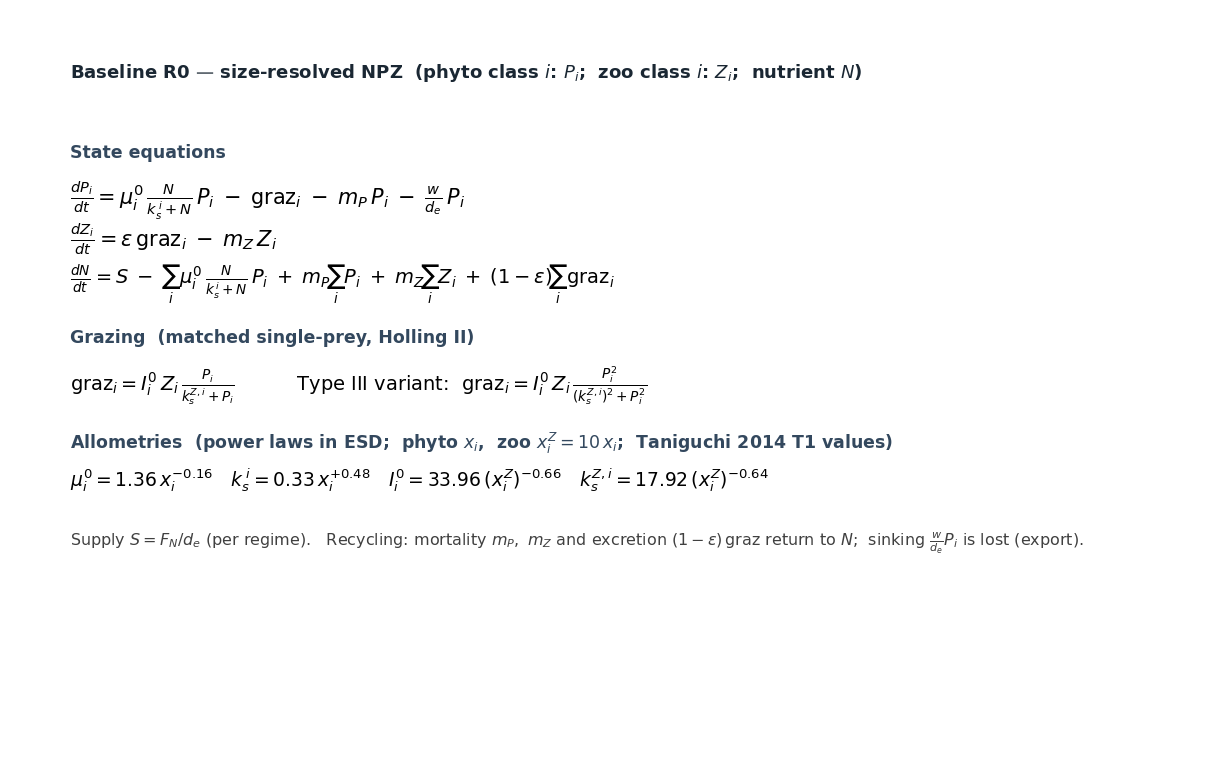

In [2]:
# ── Cell 2 — Fig 0: baseline model equations (Banas-2011 notation) ───────────
eq_blocks = [
    ("State equations",
     dict(size=12.5, weight='bold', color='#33485e', gap=0.4)),
    (r"$\frac{dP_i}{dt}=\mu^0_i\,\frac{N}{k_s^{\,i}+N}\,P_i\;-\;\mathrm{graz}_i"
     r"\;-\;m_P\,P_i\;-\;\frac{w}{d_e}\,P_i$", dict(size=15)),
    (r"$\frac{dZ_i}{dt}=\varepsilon\,\mathrm{graz}_i\;-\;m_Z\,Z_i$", dict(size=15)),
    (r"$\frac{dN}{dt}=S\;-\;\sum_i \mu^0_i\,\frac{N}{k_s^{\,i}+N}\,P_i"
     r"\;+\;m_P\!\sum_i P_i\;+\;m_Z\!\sum_i Z_i\;+\;(1-\varepsilon)\!\sum_i \mathrm{graz}_i$",
     dict(size=14)),
    ("Grazing  (matched single-prey, Holling II)",
     dict(size=12.5, weight='bold', color='#33485e', gap=0.7)),
    (r"$\mathrm{graz}_i=I^0_i\,Z_i\,\frac{P_i}{k_s^{Z,i}+P_i}$"
     r"          Type III variant:  "
     r"$\mathrm{graz}_i=I^0_i\,Z_i\,\frac{P_i^{2}}{(k_s^{Z,i})^{2}+P_i^{2}}$",
     dict(size=14)),
    (r"Allometries  (power laws in ESD;  phyto $x_i$,  zoo $x_i^{Z}=10\,x_i$;  "
     r"Taniguchi 2014 T1 values)",
     dict(size=12.5, weight='bold', color='#33485e', gap=0.7)),
    (r"$\mu^0_i=1.36\,x_i^{-0.16}\quad k_s^{\,i}=0.33\,x_i^{+0.48}\quad"
     r"I^0_i=33.96\,(x_i^{Z})^{-0.66}\quad k_s^{Z,i}=17.92\,(x_i^{Z})^{-0.64}$",
     dict(size=13.5)),
    (r"Supply $S=F_N/d_e$ (per regime).   Recycling: mortality $m_P,\ m_Z$ and "
     r"excretion $(1-\varepsilon)\,\mathrm{graz}$ return to $N$;  "
     r"sinking $\frac{w}{d_e}P_i$ is lost (export).",
     dict(size=11.5, color='0.25', gap=0.7)),
]

fig = pp.plot_equation_sheet(
    eq_blocks,
    title=r"Baseline R0 — size-resolved NPZ  "
          r"(phyto class $i$: $P_i$;  zoo class $i$: $Z_i$;  nutrient $N$)")
plt.show()

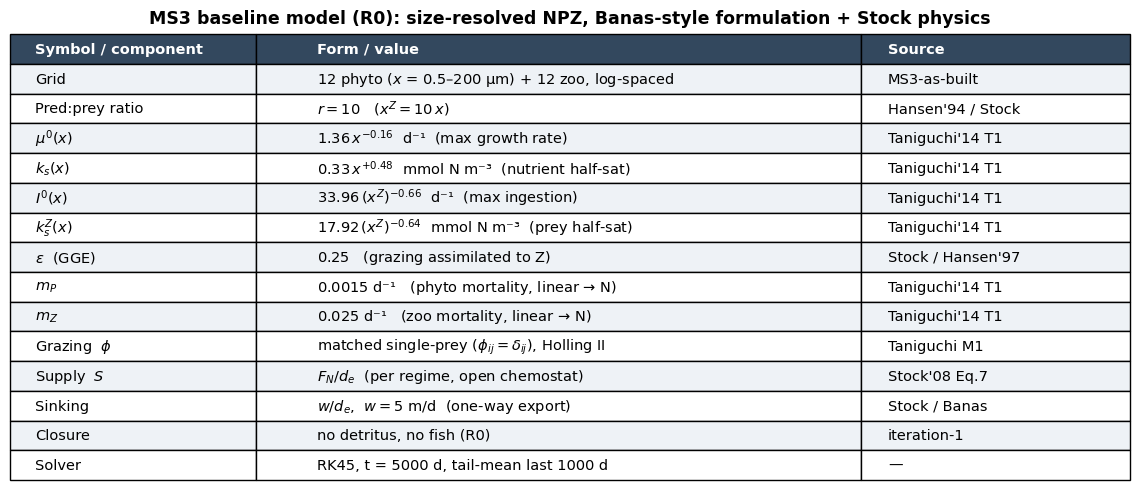

In [3]:
# ── Cell 3 — Fig 1: model structure & parameters ─────────────────────────────
lo, hi = cbs.phyto_esd[0], cbs.phyto_esd[-1]
rows = [
    ("Grid",             f"{cbs.N_CLASSES} phyto ($x$ = {lo:.2g}–{hi:.0f} µm) "
                         f"+ {cbs.N_CLASSES} zoo, log-spaced",                  "MS3-as-built"),
    ("Pred:prey ratio",  rf"$r = {cbs.ZOO_PHYTO_RATIO:.0f}$   "
                         rf"($x^{{Z}} = {cbs.ZOO_PHYTO_RATIO:.0f}\,x$)",        "Hansen'94 / Stock"),
    (r"$\mu^0(x)$",      r"$1.36\,x^{-0.16}$  d⁻¹  (max growth rate)",          "Taniguchi'14 T1"),
    (r"$k_s(x)$",        r"$0.33\,x^{+0.48}$  mmol N m⁻³  (nutrient half-sat)", "Taniguchi'14 T1"),
    (r"$I^0(x)$",        r"$33.96\,(x^{Z})^{-0.66}$  d⁻¹  (max ingestion)",     "Taniguchi'14 T1"),
    (r"$k_s^{Z}(x)$",    r"$17.92\,(x^{Z})^{-0.64}$  mmol N m⁻³  (prey half-sat)", "Taniguchi'14 T1"),
    (r"$\varepsilon$  (GGE)", f"${cbs.GAMMA_VAL}$   (grazing assimilated to Z)", "Stock / Hansen'97"),
    (r"$m_P$",           f"${cbs.LAMBDA_VAL}$ d⁻¹   (phyto mortality, linear → N)", "Taniguchi'14 T1"),
    (r"$m_Z$",           f"${cbs.DELTA_VAL}$ d⁻¹   (zoo mortality, linear → N)",    "Taniguchi'14 T1"),
    (r"Grazing  $\phi$", r"matched single-prey ($\phi_{ij}=\delta_{ij}$), Holling II", "Taniguchi M1"),
    (r"Supply  $S$",     r"$F_N/d_e$  (per regime, open chemostat)",            "Stock'08 Eq.7"),
    ("Sinking",          rf"$w/d_e$,  $w={cbs.W_SINK:.0f}$ m/d  (one-way export)", "Stock / Banas"),
    ("Closure",          "no detritus, no fish (R0)",                          "iteration-1"),
    ("Solver",           "RK45, t = 5000 d, tail-mean last 1000 d",            "—"),
]

fig = pp.plot_parameter_table(
    rows,
    title="MS3 baseline model (R0): size-resolved NPZ, "
          "Banas-style formulation + Stock physics")
plt.show()

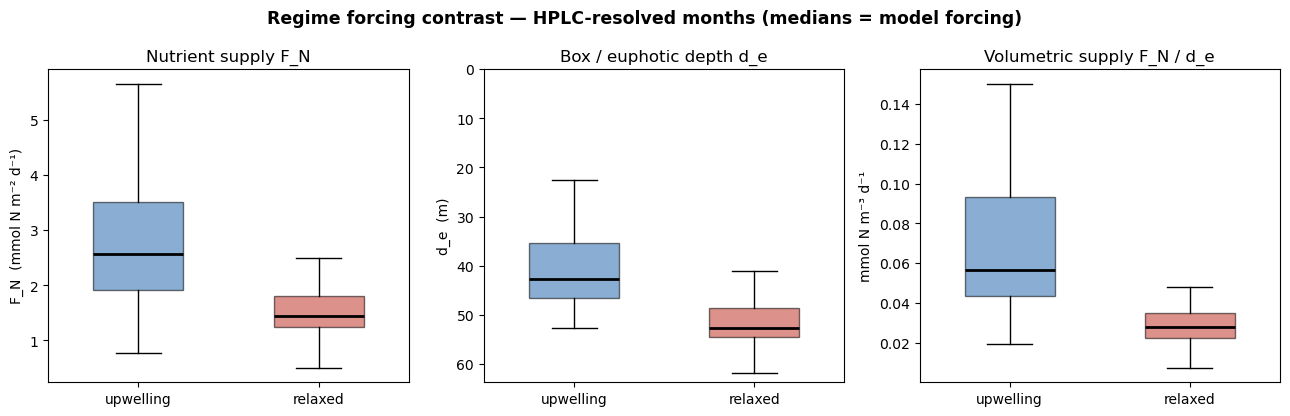

upwelling   n=31   F_N= 2.58   d_e= 42.8   F_N/d_e=0.0603
relaxed     n=58   F_N= 1.45   d_e= 52.7   F_N/d_e=0.0275


In [4]:
# ── Cell 4 — Fig 2: regime forcing (upwelling vs relaxed, HPLC months) ───────
regimes = ('upwelling', 'relaxed')

targets = {}
for r in regimes:
    obs_vec, labels, bin_defs, monthly_df, forcing = co.load_cariaco_targets(
        regime=r, months='hplc', agg='median')
    targets[r] = dict(obs_vec=obs_vec, monthly_df=monthly_df, forcing=forcing)

fig = pp.plot_regime_forcing({r: targets[r]['monthly_df'] for r in regimes},
                             regimes=regimes)
plt.show()

for r in regimes:
    f = targets[r]['forcing']
    print(f"{r:10s}  n={len(targets[r]['monthly_df']):2d}   "
          f"F_N={f['Inflow__FN']:5.2f}   d_e={f['Inflow__de']:5.1f}   "
          f"F_N/d_e={f['Inflow__FN']/f['Inflow__de']:.4f}")

upwelling   CV(ΣP)=0.29   model mcs=3.51 µm   obs mcs=4.84 µm
relaxed     CV(ΣP)=0.08   model mcs=1.58 µm   obs mcs=2.01 µm


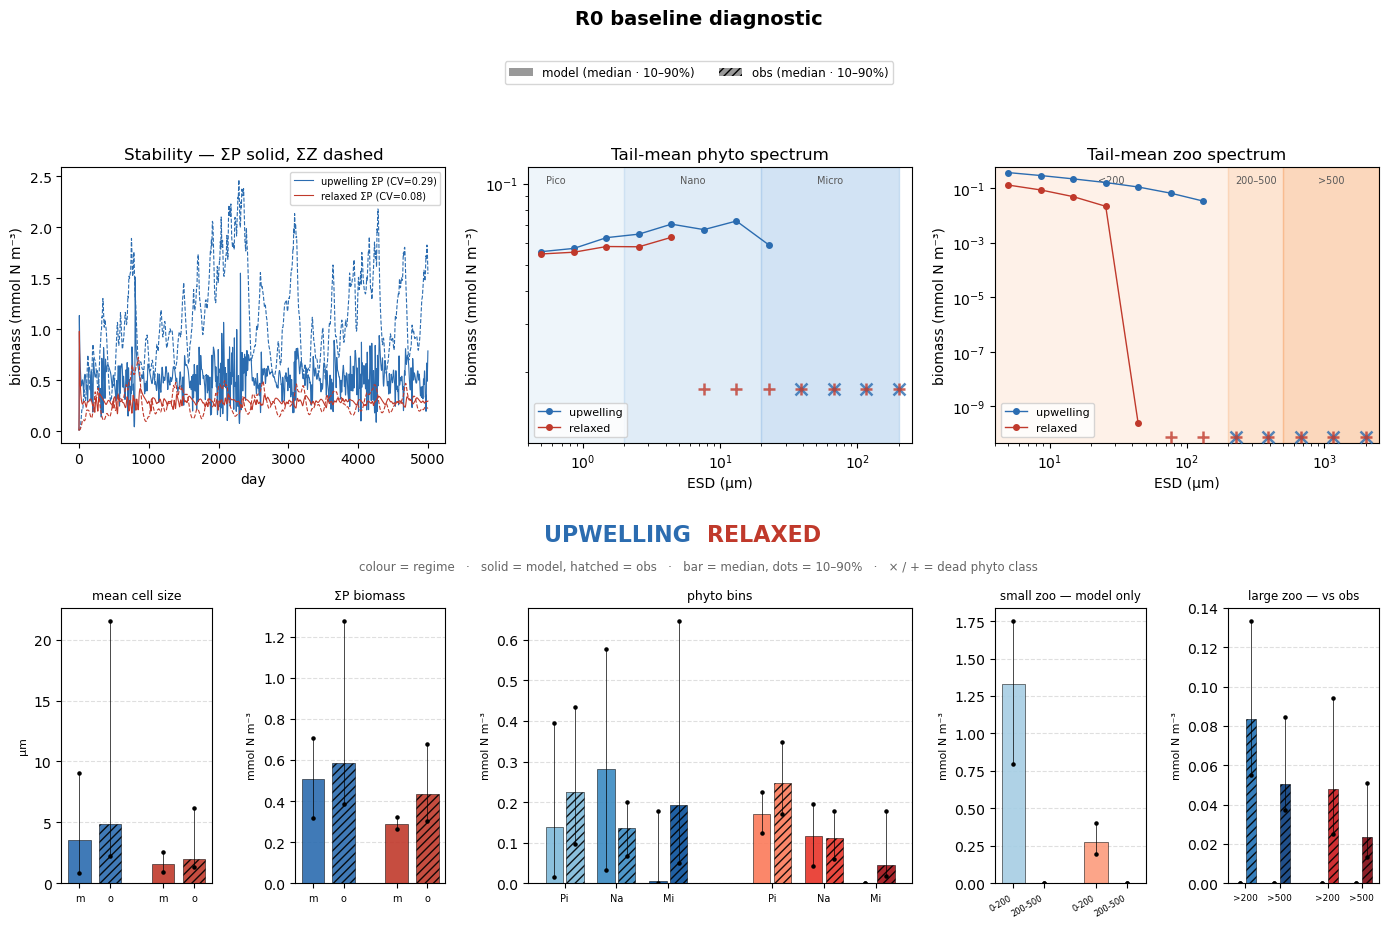

In [5]:
# ── Cell 5 — IVP runs per regime → tail-mean diagnostic vs obs (Fig 4) ───────
TAIL = 1000

model_by_regime, obs_by_regime = {}, {}
for r in regimes:
    out = pu.run_single_point(cbs.model_baseline, cbs.model_setup_baseline,
                              scan_params={}, fixed_overrides=targets[r]['forcing'])
    model_by_regime[r] = pu.process_regime_run(out, phyto_esd, zoo_esd, bin_defs,
                                               tail_len=TAIL)
    obs_by_regime[r]   = pu.process_regime_obs(targets[r]['monthly_df'], bin_defs)
    print(f"{r:10s}  CV(ΣP)={model_by_regime[r]['cv']:.2f}   "
          f"model mcs={np.nanmedian(model_by_regime[r]['mcs_tail']):.2f} µm   "
          f"obs mcs={np.nanmedian(obs_by_regime[r]['mcs']):.2f} µm")

fig = pp.plot_regime_diagnostic(model_by_regime, obs_by_regime,
                                phyto_esd, zoo_esd, regimes=regimes)
plt.show()

In [6]:
# ── Cell 7 — stability analysis: fsolve steady state + eigenvalues, seeded ───
from xso.parscans import StabilityAnalysisHook

def tail_mean_seed(out, avg_window=TAIL):
    """Flat init-slot overrides = tail-mean state of an IVP run (the fsolve seed).
    Clipped positive so Newton doesn't stall on zeros/negatives."""
    return {
        'Nutrient__value_init': float(out['Nutrient__value'].values[-avg_window:].mean()),
        'Phytoplankton__biomass_init': np.maximum(
            out['Phytoplankton__biomass'].values[:, -avg_window:].mean(axis=1), 1e-9),
        'Zooplankton__biomass_init': np.maximum(
            out['Zooplankton__biomass'].values[:, -avg_window:].mean(axis=1), 1e-9),
    }

def run_stability(model, stab_setup, forcing, seed):
    """fsolve steady state + eigenvalues at one forcing, from a given seed."""
    hook = StabilityAnalysisHook()
    with model:
        out = (stab_setup.xsimlab
               .update_vars(input_vars={**forcing, **seed})
               .xsimlab.run(hooks=[hook]))
    return out, hook.get_results()

stab_by_regime = {}
for r in regimes:
    ivp = pu.run_single_point(cbs.model_baseline, cbs.model_setup_baseline,
                              scan_params={}, fixed_overrides=targets[r]['forcing'])
    out_s, s = run_stability(cbs.model_baseline, cbs.model_setup_baseline_stability,
                             targets[r]['forcing'], tail_mean_seed(ivp))
    stab_by_regime[r] = dict(
        stab=s,
        P_ss=out_s['Phytoplankton__biomass'].isel(time=-1).values,
        Z_ss=out_s['Zooplankton__biomass'].isel(time=-1).values,
        P_tail=ivp['Phytoplankton__biomass'].values[:, -TAIL:].mean(axis=1),
        Z_tail=ivp['Zooplankton__biomass'].values[:, -TAIL:].mean(axis=1))
    print(f"{r:10s}  {s['stability']:9s}  max Re(λ)={s['max_eigenvalue_real']:+.4f}  "
          f"n_pos={s['n_positive_eigenvalues']}  n_complex_pairs={s['n_complex_pairs']}  "
          f"ΣP_ss={stab_by_regime[r]['P_ss'].sum():.3f}")

# IC robustness — same forcing, different fsolve seeds → same ecological state?
print("\nIC robustness (relaxed):")
ivp = pu.run_single_point(cbs.model_baseline, cbs.model_setup_baseline,
                          scan_params={}, fixed_overrides=targets['relaxed']['forcing'])
base = tail_mean_seed(ivp)
seeds = {
    'tail-mean':      base,
    'tail-mean x0.5': {k: v * 0.5 for k, v in base.items()},
    'tail-mean x2':   {k: v * 2.0 for k, v in base.items()},
    'uniform 0.1':    {'Nutrient__value_init': 1.0,
                       'Phytoplankton__biomass_init': np.full(cbs.N_CLASSES, 0.1),
                       'Zooplankton__biomass_init':   np.full(cbs.N_CLASSES, 0.1)},
}
for name, sd in seeds.items():
    _, s = run_stability(cbs.model_baseline, cbs.model_setup_baseline_stability,
                         targets['relaxed']['forcing'], sd)
    print(f"  {name:16s}  {s['stability']:9s}  max Re(λ)={s['max_eigenvalue_real']:+.4f}  "
          f"n_pos={s['n_positive_eigenvalues']}")

[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 1.3492e-02
upwelling   unstable   max Re(λ)=+0.0135  n_pos=13  n_complex_pairs=8  ΣP_ss=0.516
[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 2.3405e-03
relaxed     unstable   max Re(λ)=+0.0023  n_pos=7  n_complex_pairs=4  ΣP_ss=0.290

IC robustness (relaxed):
[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 2.3405e-03
  tail-mean         unstable   max Re(λ)=+0.0023  n_pos=7
[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] System stability: UNSTABLE
[HOOK] Max eigenvalue real part: 2.3405e-03
  tail-mean x0.5    unstable   max Re(λ)=+0.0023  n_pos=7
[HOOK] Detected NumericalStabilitySolver - will capture stability results
[HOOK] Syst

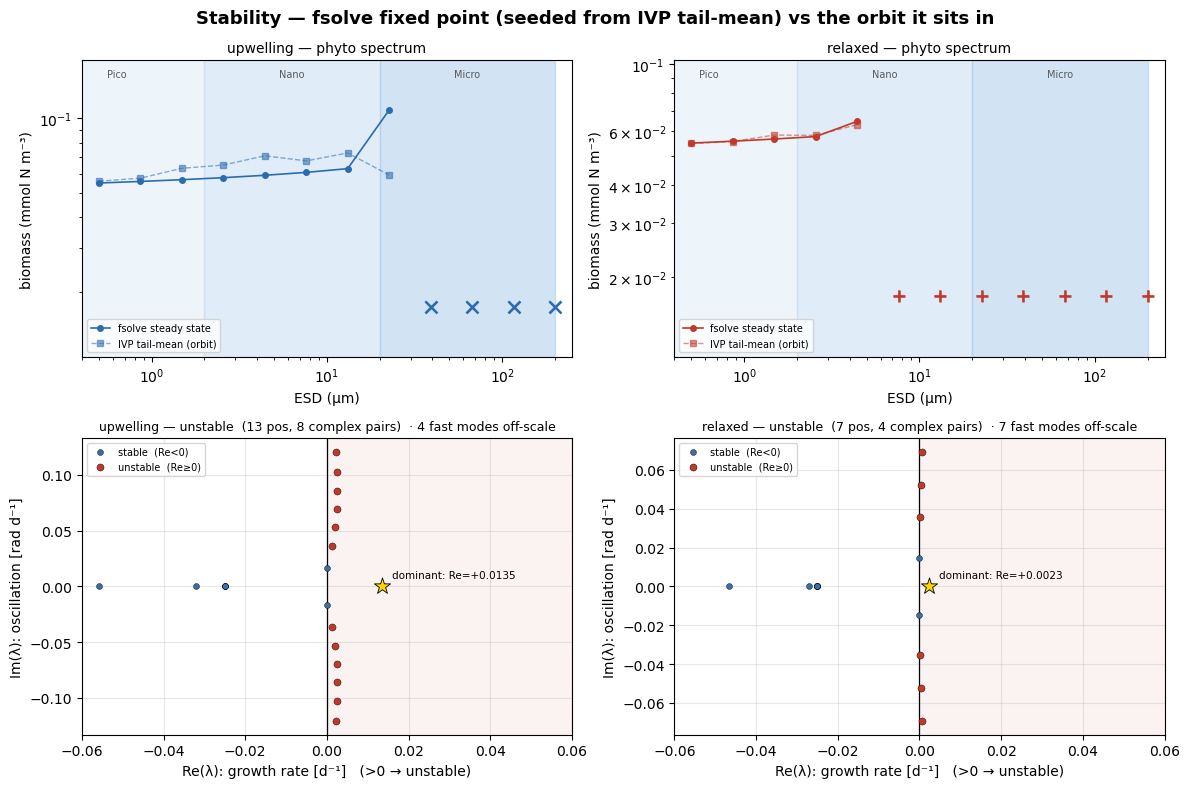

In [7]:
# ── Cell 8 — Fig 6: stability diagnostic (focus vs orbit + eigenvalues) ──────
fig = pp.plot_stability_diagnostic(stab_by_regime, phyto_esd, regimes=regimes)
plt.show()

In [8]:
# ── Cell 9 — consolidated text summary (paste this back to share results) ────
_ = pu.report_regime_diagnostic(
        model_by_regime, obs_by_regime, regimes=regimes,
        forcing_by_regime={r: targets[r]['forcing'] for r in regimes},
        stab_by_regime=stab_by_regime)

=== UPWELLING   (F_N=2.58, d_e=42.8) ===
                       model       obs     m/o
  mean cell um         3.509     4.841    0.72
  sumP mmolN/m3        0.509     0.583    0.87
  Pico frac            0.325     0.406    0.80
  Nano frac            0.663     0.248    2.68
  Micro frac           0.012     0.347    0.03
  zoo gt200            0.000     0.083    0.00
  zoo gt500            0.000     0.051    0.00
  CV(sumP)             0.294
  stability         unstable   max Re(lam)=+0.0135  13 pos, 8 pairs

=== RELAXED   (F_N=1.45, d_e=52.7) ===
                       model       obs     m/o
  mean cell um         1.585     2.013    0.79
  sumP mmolN/m3        0.289     0.436    0.66
  Pico frac            0.596     0.611    0.97
  Nano frac            0.404     0.275    1.47
  Micro frac           0.000     0.114    0.00
  zoo gt200            0.000     0.048    0.00
  zoo gt500            0.000     0.023    0.00
  CV(sumP)             0.077
  stability         unstable   max Re(lam

--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline' and setup 'model_setup_baseline_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 12 points using 8 workers...
1D Scan complete. Time taken: 8.14338 seconds.
--- Starting Parallel Scan (solve_ivp) ---
Validating model 'model_baseline_t3' and setup 'model_setup_baseline_t3_slim' from 'cariaco_baseline_setups'...
Validation successful. Proceeding with scan.
--------------------------------
Starting 1D parallel scan of 'cariaco_baseline_setups' over 12 points using 8 workers...
1D Scan complete. Time taken: 10.39597 seconds.


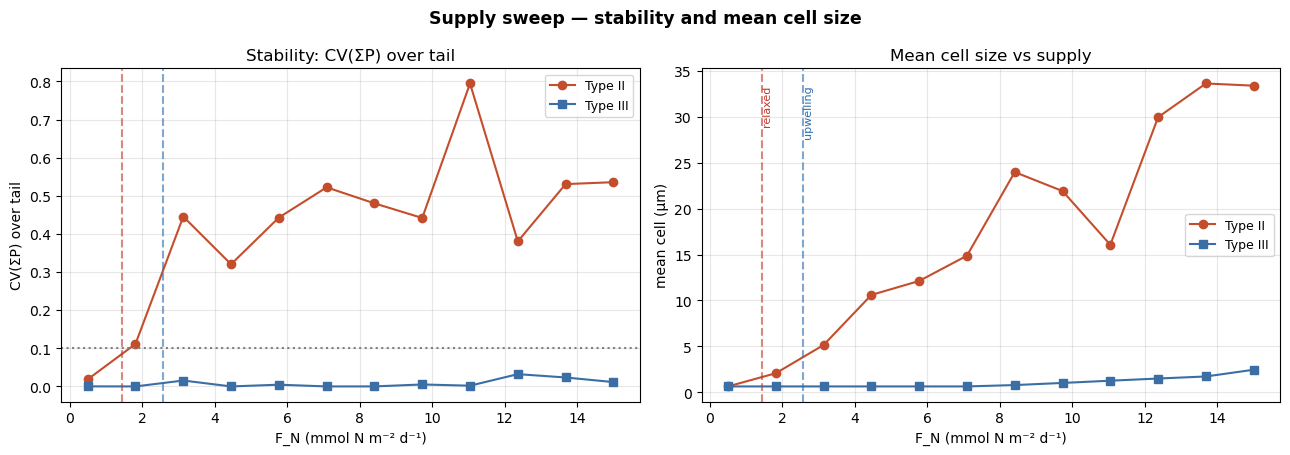

 F_N    CV_II  CV_III   mcs_II  mcs_III
 0.50   0.02    0.00     0.63     0.63
 1.82   0.11    0.00     2.07     0.63
 3.14   0.45    0.02     5.14     0.63
 4.45   0.32    0.00    10.60     0.63
 5.77   0.44    0.00    12.12     0.63
 7.09   0.52    0.00    14.87     0.63
 8.41   0.48    0.00    23.97     0.78
 9.73   0.44    0.01    21.91     1.01
11.05   0.79    0.00    16.06     1.25
12.36   0.38    0.03    29.96     1.49
13.68   0.53    0.02    33.63     1.72
15.00   0.54    0.01    33.39     2.45


In [9]:
# ── Cell 6 — supply sweep (Type II vs III): IVP CV + mean cell size vs F_N ────
fn_values = np.linspace(0.5, 15.0, 12)
DE_SWEEP  = cbs.DE_DEFAULT          # hold box depth fixed; sweep supply only

variant_setups = {
    'Type II':  ('model_baseline',    'model_setup_baseline_slim'),
    'Type III': ('model_baseline_t3', 'model_setup_baseline_t3_slim'),
}

sweep = {}
for label, (mname, sname) in variant_setups.items():
    res = run_xso_parscan(
        model_file_name='cariaco_baseline_setups',
        model_name=mname, model_setup_name=sname,
        param_name='Inflow__FN', param_values=fn_values,
        processes=8, fixed_overrides={'Inflow__de': DE_SWEEP},
    )
    cv, mcs = [], []
    for k in range(len(fn_values)):
        proc = pu.process_regime_run(res.isel({'Inflow__FN': k}),
                                     phyto_esd, zoo_esd, bin_defs, tail_len=TAIL)
        cv.append(proc['cv'])
        mcs.append(np.nanmedian(proc['mcs_tail']))
    sweep[label] = {'cv': np.array(cv), 'mean_cell': np.array(mcs)}

regime_fn = {r: targets[r]['forcing']['Inflow__FN'] for r in regimes}
fig = pp.plot_stability_scan(sweep, fn_values, regime_fn=regime_fn,
                             metric_key='cv', metric_label='CV(ΣP) over tail',
                             metric_threshold=0.1)
plt.show()

print(" F_N    CV_II  CV_III   mcs_II  mcs_III")
for k, fn in enumerate(fn_values):
    print(f"{fn:5.2f}  {sweep['Type II']['cv'][k]:5.2f}  "
          f"{sweep['Type III']['cv'][k]:6.2f}   "
          f"{sweep['Type II']['mean_cell'][k]:6.2f}  "
          f"{sweep['Type III']['mean_cell'][k]:7.2f}")